In [63]:
import os
import re
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# Fix: Disable torch.compile (dynamo) to avoid recompile limit crash
# Vision models produce variable-length sequences that trigger excessive recompilations
import torch._dynamo
torch._dynamo.config.disable = True

In [64]:
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
    device_map = "auto",  # Shard model across both GPUs
)

==((====))==  Unsloth 2026.3.11: Fast Qwen3_Vl patching. Transformers: 4.57.1.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 2. Max memory: 23.588 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.12.0+cu126. CUDA: 8.6. CUDA Toolkit: 12.6. Triton: 3.7.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.04it/s]


In [65]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

## data

In [66]:
import json
from pathlib import Path
from datasets import Dataset, DatasetDict, Image as HFImage, load_from_disk
from PIL import Image
import imageio.v3 as iio
from tqdm.auto import tqdm

DATASET_CACHE = Path("../rt1_data/dataset_cache")

def sample_frames(video_path: str) -> list:
    """Extract 4 evenly spaced frames: first, two middle, last."""
    frames = iio.imread(video_path, plugin="pyav")
    n = len(frames)
    if n < 4:
        indices = list(range(n))
    else:
        indices = [0, n // 3, 2 * n // 3, n - 1]
    return [Image.fromarray(frames[i]) for i in indices]

def load_rt1_split(split_dir: Path, desc: str = "Loading") -> Dataset:
    records = []
    json_files = sorted(f for f in split_dir.glob("*.json") if f.name != "manifest.json")
    for json_path in tqdm(json_files, desc=desc):
        meta = json.loads(json_path.read_text())
        video_path = str(split_dir / meta["video"])
        imgs = sample_frames(video_path)
        records.append({
            "frame_0": imgs[0],
            "frame_1": imgs[1] if len(imgs) > 1 else imgs[0],
            "frame_2": imgs[2] if len(imgs) > 2 else imgs[-1],
            "frame_3": imgs[3] if len(imgs) > 3 else imgs[-1],
            "instruction": meta["instruction"],
            "success": meta["success"],
        })
    return Dataset.from_list(records).cast_column("frame_0", HFImage()).cast_column("frame_1", HFImage()).cast_column("frame_2", HFImage()).cast_column("frame_3", HFImage())

if DATASET_CACHE.exists():
    print("Loading cached dataset...")
    dataset = load_from_disk(str(DATASET_CACHE))
else:
    print("Extracting frames from videos (one-time)...")
    rt1_root = Path("../rt1_data")
    dataset = DatasetDict({
        "train": load_rt1_split(rt1_root / "train", desc="Train"),
        "test": load_rt1_split(rt1_root / "test", desc="Test"),
    })
    dataset.save_to_disk(str(DATASET_CACHE))
    print(f"Saved to {DATASET_CACHE}")

dataset

Loading cached dataset...


DatasetDict({
    train: Dataset({
        features: ['frame_0', 'frame_1', 'frame_2', 'frame_3', 'instruction', 'success'],
        num_rows: 1360
    })
    test: Dataset({
        features: ['frame_0', 'frame_1', 'frame_2', 'frame_3', 'instruction', 'success'],
        num_rows: 340
    })
})

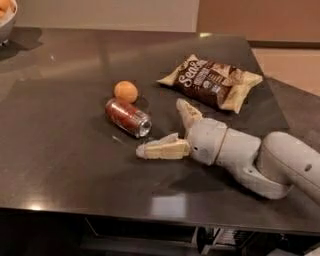

In [67]:
dataset["train"][0]["frame_3"]

In [68]:
def convert_to_conversation(sample):
    instruction = sample["instruction"]
    success = sample["success"]

    prompt = f"""Here is a sequence of frames from a robot policy which has been \
rolled out in a video-generation-based world model. I need your help \
determining whether the policy is successful. How successfully does \
the robot complete the following task?

## Task Description: "{instruction}"

## Score rubric:
Failure: instruction "{instruction}" not completed.
Success: instruction completed.

## Answer Format
Place your final answer in <answer></answer> tags. For example if the robot \
completed the task, your answer would be:
<answer>Success</answer>

If the robot did not complete the task, your answer would be:
<answer>Failure</answer>
"""

    response = "<answer>Success</answer>" if success else "<answer>Failure</answer>"

    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : prompt},
            {"type" : "image", "image" : sample["frame_0"]},
            {"type" : "image", "image" : sample["frame_1"]},
            {"type" : "image", "image" : sample["frame_2"]},
            {"type" : "image", "image" : sample["frame_3"]},
          ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : response} ]
        },
    ]
    return { "messages" : conversation }

train_dataset = [convert_to_conversation(sample) for sample in dataset["train"]]
train_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Here is a sequence of frames from a robot policy which has been rolled out in a video-generation-based world model. I need your help determining whether the policy is successful. How successfully does the robot complete the following task?\n\n## Task Description: "place coke can upright"\n\n## Score rubric:\nFailure: instruction "place coke can upright" not completed.\nSuccess: instruction completed.\n\n## Answer Format\nPlace your final answer in <answer></answer> tags. For example if the robot completed the task, your answer would be:\n<answer>Success</answer>\n\nIf the robot did not complete the task, your answer would be:\n<answer>Failure</answer>\n'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x256>},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x256>},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.Pn

**User prompt:**

```
Here is a sequence of frames from a robot policy which has been rolled out in a video-generation-based world model. I need your help determining whether the policy is successful. How successfully does the robot complete the following task?

## Task Description: "move brown chip bag near blue chip bag"

## Score rubric:
Failure: instruction "move brown chip bag near blue chip bag" not completed.
Success: instruction completed.

## Answer Format
Place your final answer in <answer></answer> tags. For example if the robot completed the task, your answer would be:
<answer>Success</answer>

If the robot did not complete the task, your answer would be:
<answer>Failure</answer>

```

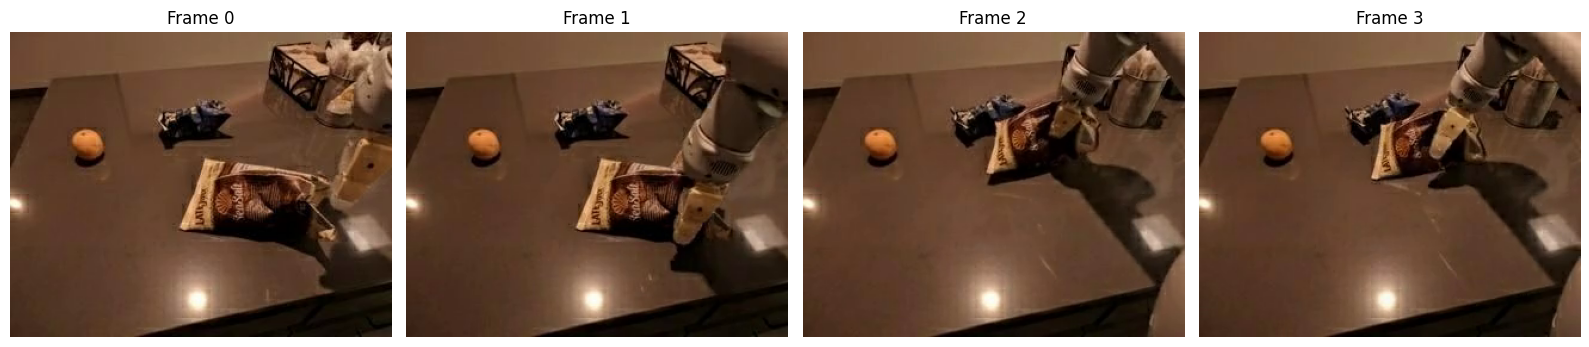

**Assistant response:** `<answer>Success</answer>` (Success)

In [69]:
import random
from IPython.display import display, Markdown

def preview_random_conversation(only_failures=False):
    pool = train_dataset
    if only_failures:
        pool = [s for s in train_dataset if "Success" not in s["messages"][1]["content"][0]["text"]]

    sample = pool[random.randint(0, len(pool) - 1)]
    msgs = sample["messages"]
    user_content = msgs[0]["content"]
    assistant_content = msgs[1]["content"]

    # Display prompt text
    prompt_text = user_content[0]["text"]
    display(Markdown(f"**User prompt:**\n\n```\n{prompt_text}\n```"))

    # Display frames side by side
    images = [item["image"] for item in user_content if item["type"] == "image"]
    fig, axes = __import__("matplotlib").pyplot.subplots(1, len(images), figsize=(16, 4))
    if len(images) == 1:
        axes = [axes]
    for i, (ax, img) in enumerate(zip(axes, images)):
        ax.imshow(img)
        ax.set_title(f"Frame {i}")
        ax.axis("off")
    __import__("matplotlib").pyplot.tight_layout()
    __import__("matplotlib").pyplot.show()

    # Display response
    response = assistant_content[0]["text"]
    label = "Success" if "Success" in response else "Failure"
    display(Markdown(f"**Assistant response:** `{response}` ({label})"))

preview_random_conversation(only_failures=False)

# Training

**Prompt:**

```
Here is a sequence of frames from a robot policy which has been rolled out in a video-generation-based world model. I need your help determining whether the policy is successful. How successfully does the robot complete the following task?

## Task Description: "pick rxbar chocolate"

## Score rubric:
Failure: instruction "pick rxbar chocolate" not completed.
Success: instruction completed.

## Answer Format
Place your final answer in <answer></answer> tags. For example if the robot completed the task, your answer would be:
<answer>Success</answer>

If the robot did not complete the task, your answer would be:
<answer>Failure</answer>

```

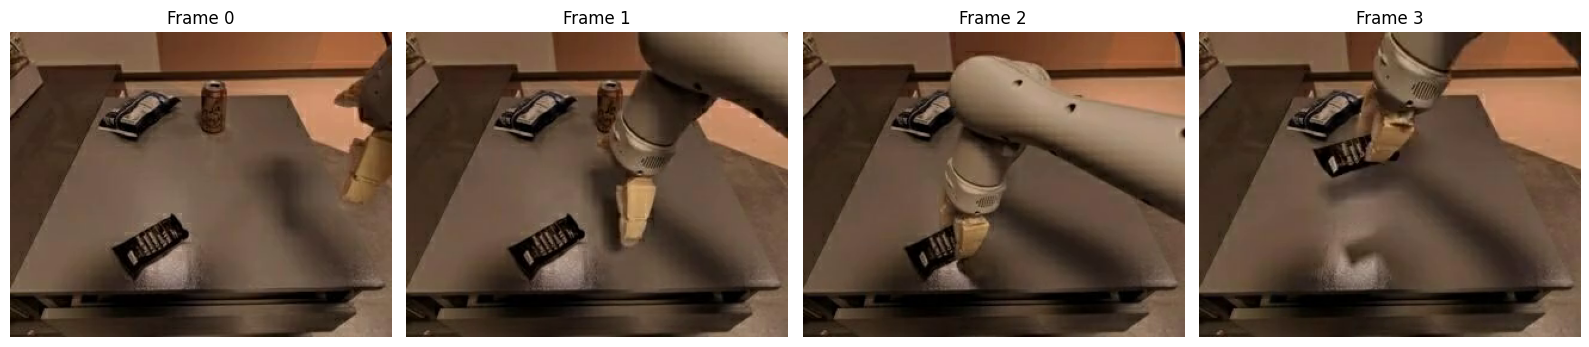

**Ground truth:** Failure

**Model output:** `<answer>Success</answer><|im_end|>`

In [70]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from transformers import TextStreamer
import io, sys

FastVisionModel.for_inference(model)

random_num = random.randint(0, len(dataset["test"]) - 1)
sample = dataset["test"][random_num]
instruction = sample["instruction"]
images = [sample["frame_0"], sample["frame_1"], sample["frame_2"], sample["frame_3"]]
ground_truth = "Success" if sample["success"] else "Failure"

prompt = f"""Here is a sequence of frames from a robot policy which has been \
rolled out in a video-generation-based world model. I need your help \
determining whether the policy is successful. How successfully does \
the robot complete the following task?

## Task Description: "{instruction}"

## Score rubric:
Failure: instruction "{instruction}" not completed.
Success: instruction completed.

## Answer Format
Place your final answer in <answer></answer> tags. For example if the robot \
completed the task, your answer would be:
<answer>Success</answer>

If the robot did not complete the task, your answer would be:
<answer>Failure</answer>
"""

# --- Visualize input ---
display(Markdown(f"**Prompt:**\n\n```\n{prompt}\n```"))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (ax, img) in enumerate(zip(axes, images)):
    ax.imshow(img)
    ax.set_title(f"Frame {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()

display(Markdown(f"**Ground truth:** {ground_truth}"))

# --- Run inference ---
messages = [
    {"role": "user", "content": [
        {"type": "text", "text": prompt},
        {"type": "image"},
        {"type": "image"},
        {"type": "image"},
        {"type": "image"},
    ]}
]

input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
inputs = tokenizer(
    images,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

# Capture streamed output
buf = io.StringIO()
old_stdout = sys.stdout
sys.stdout = buf
text_streamer = TextStreamer(tokenizer, skip_prompt=True)
_ = model.generate(**inputs, streamer=text_streamer, max_new_tokens=128,
                   use_cache=True, temperature=1.5, min_p=0.1)
sys.stdout = old_stdout
model_output = buf.getvalue().strip()

display(Markdown(f"**Model output:** `{model_output}`"))

In [71]:
from transformers import TrainerCallback

# Pre-build eval inputs from the full test split
eval_samples = []
for idx in range(len(dataset["test"])):
    sample = dataset["test"][idx]
    instruction = sample["instruction"]
    ground_truth = "Success" if sample["success"] else "Failure"
    images = [sample["frame_0"], sample["frame_1"], sample["frame_2"], sample["frame_3"]]

    prompt = f"""Here is a sequence of frames from a robot policy which has been \
rolled out in a video-generation-based world model. I need your help \
determining whether the policy is successful. How successfully does \
the robot complete the following task?

## Task Description: "{instruction}"

## Score rubric:
Failure: instruction "{instruction}" not completed.
Success: instruction completed.

## Answer Format
Place your final answer in <answer></answer> tags. For example if the robot \
completed the task, your answer would be:
<answer>Success</answer>

If the robot did not complete the task, your answer would be:
<answer>Failure</answer>
"""
    eval_samples.append((images, prompt, ground_truth))

print(f"Prepared {len(eval_samples)} eval samples from test set")


class EvalCallback(TrainerCallback):
    """Evaluates once per epoch by generating predictions on the full test set."""

    def __init__(self, eval_samples, tokenizer, steps_per_epoch):
        self.eval_samples = eval_samples
        self.tokenizer = tokenizer
        self.steps_per_epoch = steps_per_epoch
        self.metrics = {"step": [], "epoch": [], "accuracy": [], "tpr": [], "tnr": [], "fpr": [], "fnr": []}
        self.train_log = {"step": [], "loss": []}
        self.best_accuracy = -1.0
        self.best_step = -1
        self.best_epoch = -1

    def _evaluate(self, model, step, epoch):
        was_training = model.training
        model.eval()

        tp = fp = tn = fn = unk = 0
        with torch.no_grad():
            for images, prompt, gt in self.eval_samples:
                messages = [{"role": "user", "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image"}, {"type": "image"},
                    {"type": "image"}, {"type": "image"},
                ]}]
                input_text = self.tokenizer.apply_chat_template(messages, add_generation_prompt=True)
                inputs = self.tokenizer(
                    images, input_text,
                    add_special_tokens=False, return_tensors="pt",
                ).to("cuda")
                out_ids = model.generate(
                    **inputs, max_new_tokens=32, use_cache=True, temperature=1.0,
                )
                text = self.tokenizer.decode(
                    out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True,
                )
                m = re.search(r"<answer>\s*(Success|Failure)\s*</answer>", text)
                if m:
                    pred = m.group(1)
                    if   pred == "Success" and gt == "Success": tp += 1
                    elif pred == "Success" and gt == "Failure": fp += 1
                    elif pred == "Failure" and gt == "Failure": tn += 1
                    else:                                       fn += 1
                else:
                    unk += 1

        total = tp + fp + tn + fn + unk
        acc = (tp + tn) / total if total else 0
        tpr = tp / (tp + fn) if (tp + fn) else 0
        tnr = tn / (tn + fp) if (tn + fp) else 0
        fpr = fp / (fp + tn) if (fp + tn) else 0
        fnr = fn / (fn + tp) if (fn + tp) else 0

        self.metrics["step"].append(step)
        self.metrics["epoch"].append(epoch)
        self.metrics["accuracy"].append(acc)
        self.metrics["tpr"].append(tpr)
        self.metrics["tnr"].append(tnr)
        self.metrics["fpr"].append(fpr)
        self.metrics["fnr"].append(fnr)

        tag = ""
        if acc > self.best_accuracy:
            self.best_accuracy = acc
            self.best_step = step
            self.best_epoch = epoch
            tag = " ★ new best"
            model.save_pretrained("outputs/best_checkpoint")
            self.tokenizer.save_pretrained("outputs/best_checkpoint")

        print(f"  [Epoch {epoch:.1f} / step {step}] Acc={acc:.1%}  TPR={tpr:.1%}  TNR={tnr:.1%}  |  TP:{tp} FP:{fp} TN:{tn} FN:{fn} Unk:{unk}{tag}")

        if was_training:
            model.train()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.train_log["step"].append(state.global_step)
            self.train_log["loss"].append(logs["loss"])

    def on_train_begin(self, args, state, control, **kwargs):
        print("Running baseline eval (epoch 0)...")
        self._evaluate(kwargs["model"], 0, 0)

    def on_epoch_end(self, args, state, control, **kwargs):
        epoch = state.epoch or (state.global_step / self.steps_per_epoch)
        self._evaluate(kwargs["model"], state.global_step, epoch)


eval_callback = EvalCallback(eval_samples, tokenizer, steps_per_epoch=170)
print("EvalCallback ready")

Prepared 340 eval samples from test set
EvalCallback ready


In [72]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = train_dataset,
    callbacks = [eval_callback],
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        num_train_epochs = 3,
        learning_rate = 5e-5,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
        bf16 = True,

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [73]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,360 | Num Epochs = 3 | Total steps = 510
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 51,346,944 of 8,818,470,640 (0.58% trained)


Running baseline eval (epoch 0)...


/home/log/Github/WorldEvals/.venv/lib/python3.11/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  [Epoch 0.0 / step 0] Acc=70.9%  TPR=87.2%  TNR=50.7%  |  TP:164 FP:75 TN:77 FN:24 Unk:0 ★ new best


Step,Training Loss
1,3.568700
2,3.567300
3,3.532400
4,3.526500
5,3.447500
6,3.379200
7,3.220300
8,2.961400
9,2.756400
10,2.492700


  [Epoch 1.0 / step 170] Acc=72.1%  TPR=82.4%  TNR=59.2%  |  TP:155 FP:62 TN:90 FN:33 Unk:0 ★ new best
  [Epoch 2.0 / step 340] Acc=75.3%  TPR=83.5%  TNR=65.1%  |  TP:157 FP:53 TN:99 FN:31 Unk:0 ★ new best


/home/log/Github/WorldEvals/.venv/lib/python3.11/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  [Epoch 3.0 / step 510] Acc=74.4%  TPR=81.4%  TNR=65.8%  |  TP:153 FP:52 TN:100 FN:35 Unk:0


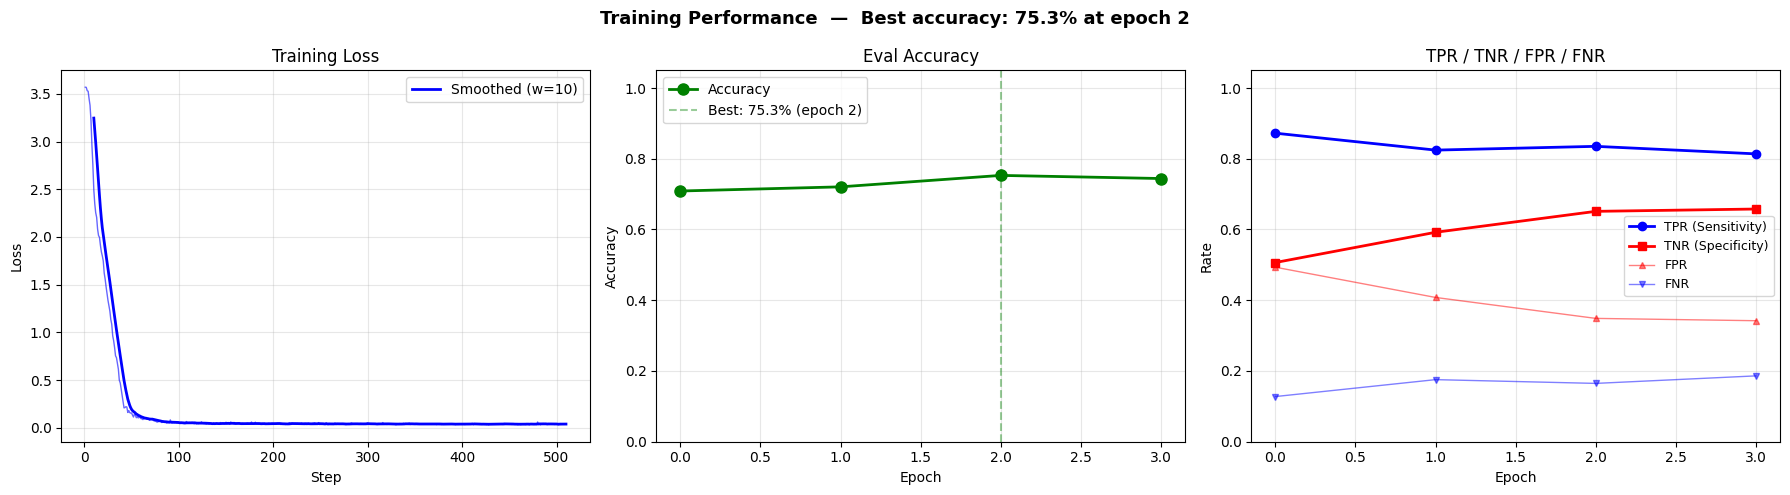


Best checkpoint: outputs/best_checkpoint  (epoch 2, step 340, accuracy 75.3%)


In [75]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Training loss ---
if eval_callback.train_log["step"]:
    axes[0].plot(eval_callback.train_log["step"], eval_callback.train_log["loss"],
                 "b-", alpha=0.6, linewidth=1)
    # Smoothed loss (rolling avg)
    window = min(10, len(eval_callback.train_log["loss"]))
    if window > 1:
        import numpy as np
        loss_arr = np.array(eval_callback.train_log["loss"])
        smoothed = np.convolve(loss_arr, np.ones(window)/window, mode="valid")
        axes[0].plot(eval_callback.train_log["step"][window-1:], smoothed,
                     "b-", linewidth=2, label=f"Smoothed (w={window})")
        axes[0].legend()
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].grid(True, alpha=0.3)

# --- Accuracy ---
epochs = eval_callback.metrics["epoch"]
axes[1].plot(epochs, eval_callback.metrics["accuracy"], "g-o", markersize=8, linewidth=2, label="Accuracy")
if eval_callback.best_epoch >= 0:
    axes[1].axvline(x=eval_callback.best_epoch, color="g", linestyle="--", alpha=0.4,
                    label=f"Best: {eval_callback.best_accuracy:.1%} (epoch {eval_callback.best_epoch:.0f})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Eval Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

# --- TPR / TNR ---
axes[2].plot(epochs, eval_callback.metrics["tpr"], "b-o", markersize=6, linewidth=2, label="TPR (Sensitivity)")
axes[2].plot(epochs, eval_callback.metrics["tnr"], "r-s", markersize=6, linewidth=2, label="TNR (Specificity)")
axes[2].plot(epochs, eval_callback.metrics["fpr"], "r-^", markersize=5, linewidth=1, alpha=0.5, label="FPR")
axes[2].plot(epochs, eval_callback.metrics["fnr"], "b-v", markersize=5, linewidth=1, alpha=0.5, label="FNR")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Rate")
axes[2].set_title("TPR / TNR / FPR / FNR")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1.05)

fig.suptitle(
    f"Training Performance  —  Best accuracy: {eval_callback.best_accuracy:.1%} at epoch {eval_callback.best_epoch:.0f}",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig("outputs/training_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBest checkpoint: outputs/best_checkpoint  (epoch {eval_callback.best_epoch:.0f}, step {eval_callback.best_step}, accuracy {eval_callback.best_accuracy:.1%})")